### **3. PATSTĀVĪGAIS DARBS. Klasifikācija**

# Modeļu trenēšana, validācija un salīdzināšana

## 1. uzdevums. Sagatavo datus modelēšanai

 ### 1.1. Ielādē tīro datu kopu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Datu fails: ja ceļš atšķiras, pielāgo to savam repozitorijam.
# Drošāka ielāde: mēģinām sākotnējo ceļu, ja neatrod — failu šajā mapē.
try:
    df = pd.read_csv('../week2/shoppers_clean.csv')
except FileNotFoundError:
    df = pd.read_csv('shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
df.head()

Datu kopa: 12330 rindas, 30 kolonnas


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,TotalDuration,BounceExitRatio,ProductBrowsingIntensity
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,1,0.000000,0.995025,1000.000000
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0,0,0,0,0,0,1,64.000000,0.000000,0.031250
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,1,0.000000,0.995025,1000.000000
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0,0,0,0,0,0,1,2.666667,0.354610,0.749719
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0,0,0,0,0,0,1,627.500000,0.392157,0.015936


 ### 1.2. Definē X un y

In [2]:
# Target mainīgais — vai klients veica pirkumu
y = df['Revenue']

# Features — visas pārējās kolonnas
X = df.drop('Revenue', axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target sadalījums:\n{y.value_counts()}")
print(f"\nPirkumu īpatsvars: {y.mean():.1%}")

Features skaits: 29
Target sadalījums:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Pirkumu īpatsvars: 15.5%


### 1.3. Sadali datos treniņa un testa kopās

### Datu sadalīšana un stratifikācija
Izmantojām `stratify=y`, lai nodrošinātu, ka mērķa mainīgā (`y`) sadalījums treniņa un testa kopās saglabājas līdzīgs kā sākotnējā datu kopā. Tas ir īpaši svarīgi klasifikācijas uzdevumos, kur klases var būt nesabalansētas — bez stratifikācijas viena no kopām var saturēt pārāk daudz vai pārāk maz kādas klases.

Pēc datu sadalīšanas attēlojam klašu sadalījumu treniņa kopā, izmantojot `y_train.value_counts(normalize=True)`, lai skaidri redzētu katras klases proporcijas. Tas palīdz pārliecināties, ka stratifikācija ir strādājusi pareizi un treniņa dati ir reprezentatīvi.

Datu sadalījums 80/20 (80% treniņam, 20% testam) ir bieži izmantots kompromiss starp modeļa apmācību un novērtēšanu. Lielāka treniņa kopa ļauj modelim labāk iemācīties datu struktūru, savukārt testa kopa joprojām ir pietiekami liela, lai ticami novērtētu modeļa veiktspēju uz neredzētiem datiem.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")

print(f"\nTarget sadalījums treniņa kopā:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTarget sadalījums testa kopā:\n{y_test.value_counts(normalize=True).round(3)}")

Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas

Target sadalījums treniņa kopā:
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64

Target sadalījums testa kopā:
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64


Treniņa un testa kopu target sadalījums ir līdzīgs (~15% pirkumi).

## 2. uzdevums. Trenē pirmo modeli — Decision Tree

### 2.1. Uztrenē Decision Tree klasifikatoru

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Izveido un uztrenē modeli
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Prognozes uz testa kopas
dt_pred = dt_model.predict(X_test)
print("=== Decision Tree rezultāti ===")
print(classification_report(y_test, dt_pred))

=== Decision Tree rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.71      0.58      0.64       382

    accuracy                           0.90      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.90      0.89      2466



### Modeļa novērtējums (Decision Tree)
Šajā solī mēs novērtējam modeļa veiktspēju, izmantojot `classification_report`, kas parāda precision, recall un F1-score katrai klasei.
 
#### Precision (precizitāte)
#Precision rāda, cik precīzi modelis prognozē konkrēto klasi. Piemēram, cik no visiem gadījumiem, kur modelis prognozēja “pirkums”, tiešām bija pirkumi.

#### Recall (pilnīgums)
Recall rāda, cik daudz no visiem reālajiem pirkumiem modelis ir atradis. Zems recall nozīmē, ka daļa pircēju tiek palaista garām.

#### F1-score
F1-score apvieno precision un recall vienā rādītājā, tāpēc tas ir īpaši noderīgs, ja klases ir nesabalansētas.

 ---

#### Rezultātu interpretācija
 - Klase 0 (nav pirkuma) tiek prognozēta ļoti labi (augsts precision un recall ~0.92–0.96)
 - Klase 1 (pirkums) ir vājāka (recall ~0.58), kas nozīmē, ka daļa pircēju tiek palaisti garām
 
 ---
 
 #### Overfitting analīze
 Lai novērtētu overfitting, būtu jāsalīdzina train un test rezultāti:
 - Ja train rezultāti ir būtiski labāki nekā test, modelis ir pārāk pielāgojies datiem
 - Ja līdzīgi, modelis vispārina labi

 ### Modeļa novērtējums (Decision Tree)
 Šajā solī mēs novērtējam modeļa veiktspēju, salīdzinot rezultātus uz treniņa un testa datiem, izmantojot accuracy un F1 score.
 
 #### Accuracy (precizitāte kopumā)
 Accuracy rāda, cik procentos gadījumu modelis ir pareizi prognozējis rezultātu.
 To aprēķinām gan treniņa, gan testa kopai, lai salīdzinātu modeļa vispārējo veiktspēju.
 
 #### F1 score
F1 score ir līdzsvarots rādītājs starp precision un recall.
 Tas ir īpaši noderīgs, ja klases nav līdzsvarotas, jo tas ņem vērā gan kļūdaini pozitīvos, gan palaistos pozitīvos gadījumus.
 
 ---
 
 #### Overfitting analīze
 Salīdzinām train un test rezultātus:
 
 - Ja train accuracy un F1 ir būtiski augstāki nekā test, tas norāda uz overfitting (modelis ir pārāk pielāgojies treniņa datiem)
 - Ja rezultāti ir līdzīgi, modelis labi vispārina uz jauniem datiem

### 2.2. Confusion matrix

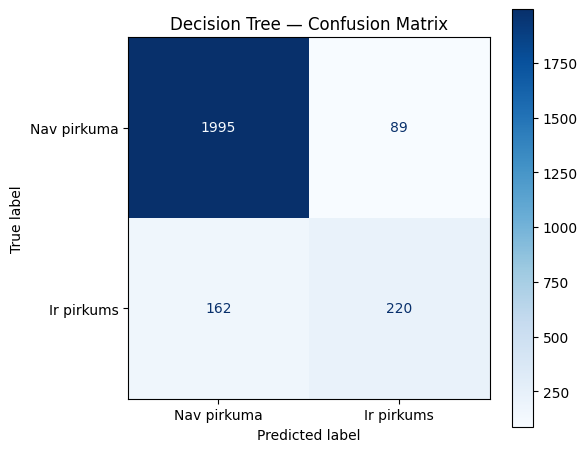

[Decision Tree] TN=1995, FP=89, FN=162, TP=220
[Decision Tree] Mini: FP=89 (izmaksas), FN=162 (zaudēts pircējs)


In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
y_test, dt_pred,
display_labels=['Nav pirkuma', 'Ir pirkums'],
cmap='Blues', ax=ax
)
ax.set_title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

# (MINI SECINĀJUMS) Decision Tree (TEST):
cm = confusion_matrix(y_test, dt_pred)
tn, fp, fn, tp = cm.ravel()
print(f"[Decision Tree] TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"[Decision Tree] Mini: FP={fp} (izmaksas), FN={fn} (zaudēts pircējs)")

### Modeļa novērtējums, izmantojot confusion matrix
Confusion matrix ir klasifikācijas modeļa novērtēšanas metode, kas parāda prognozēto un faktisko klašu sadalījumu. 
Šajā gadījumā tiek analizētas divas klases: “Nav pirkuma” (0) un “Ir pirkums” (1).
Tā ļauj detalizēti izvērtēt modeļa precizitāti un kļūdu veidus.
 
 ---
 
#### Confusion matrix interpretācija
Confusion matrix parāda modeļa prognožu sadalījumu:
 - **TP (True Positive)** — pareizi noteikts pirkums (klients pirka un modelis to paredzēja)
 - **TN (True Negative)** — pareizi noteikts, ka pirkuma nebija
 - **FP (False Positive)** — modelis paredzēja pirkumu, bet klients nepirka  
   → DataShop kontekstā tas nozīmē, ka nosūtījām atlaidi klientam, kurš nepirka (mārketinga budžeta izšķērdēšana)
 - **FN (False Negative)** — modelis neparedzēja pirkumu, bet klients patiesībā pirka  
   → tas nozīmē zaudētu potenciālo klientu, jo viņam netika piedāvāta atlaide
 
 ---
 
 #### Empīriskie rezultāti
 Balstoties uz iegūto confusion matrix:
 - **TP = 220**
 - **TN = 1995**
 - **FP = 89**
 - **FN = 162**
 
 ---
 
 #### Precision un Recall interpretācija
 
 - **Precision (≈ 0.71)** — no visiem gadījumiem, kuros modelis prognozē pirkumu, aptuveni 71% gadījumu prognoze ir pareiza.
 - **Recall (≈ 0.58)** — modelis identificē tikai aptuveni 58% no visiem faktiskajiem pirkumiem, savukārt ~42% pircēju netiek atklāti.
 
 ---
 
 #### Biznesa interpretācija
 
 No biznesa perspektīvas būtiskāka ir **false negative (FN)** kļūda nekā **false positive (FP)**, jo FN nozīmē zaudētus potenciālos klientus un neiegūtus ieņēmumus, savukārt FP rada tikai papildu mārketinga izmaksas.
 Tādēļ šajā lietojumā prioritāte būtu modeļa **recall uzlabošana**, lai palielinātu atklāto pircēju skaitu.
 
 ---
 
 #### Overfitting novērtējums
 
 Modeļa vispārināšanas spēja tiek vērtēta, salīdzinot treniņa un testa datu rezultātus. Ja treniņa datu precizitāte un F1-score būtiski pārsniedz testa datu rādītājus, tas norāda uz overfitting jeb pārmērīgu pielāgošanos treniņa datiem.
 
 Šajā gadījumā var novērot nelielas overfitting pazīmes, tomēr atšķirība starp treniņa un testa rezultātiem nav kritiska, kas norāda uz salīdzinoši stabilu modeļa vispārināšanas spēju.
 

### 2.3. Pārbauda overfitting (train vs test)

In [6]:
from sklearn.metrics import accuracy_score, f1_score
dt_train_pred = dt_model.predict(X_train)

print(f"Train accuracy: {accuracy_score(y_train, dt_train_pred):.3f}")
print(f"Test accuracy: {accuracy_score(y_test, dt_pred):.3f}")
print(f"\nTrain F1: {f1_score(y_train, dt_train_pred):.3f}")
print(f"Test F1: {f1_score(y_test, dt_pred):.3f}")

Train accuracy: 0.912
Test accuracy: 0.898

Train F1: 0.683
Test F1: 0.637


### Modeļa veiktspēja tiek novērtēta, salīdzinot rezultātus uz treniņa un testa datiem, izmantojot accuracy un F1-score.  
Train accuracy (0.912) ir nedaudz augstāks nekā test accuracy (0.898), kas norāda uz labu, bet ne perfektu vispārināšanu.  
Līdzīgi arī F1-score samazinās no 0.683 (train) līdz 0.637 (test), kas parāda nelielu veiktspējas kritumu uz jauniem datiem.  
Šīs atšķirības liecina par nelielām overfitting pazīmēm, taču tās nav būtiskas.  
Kopumā modelis uzrāda stabilu veiktspēju gan treniņa, gan testa datos.

### Kopējais modeļa novērtējuma kopsavilkums
Izveidotais klasifikācijas modelis demonstrē labu vispārējo veiktspēju pirkumu prognozēšanas uzdevumā. 
#- Modeļa precision pirkumu klasei ir aptuveni 0.71, kas norāda, ka lielākā daļa prognozēto pirkumu ir korekti, tomēr pastāv noteikts false positive kļūdu īpatsvars.
 - Savukārt recall ir aptuveni 0.58, kas nozīmē, ka modelis identificē tikai daļu no visiem faktiskajiem pirkumiem, bet ievērojamu daļu (aptuveni 42%) palaida garām, kas biznesa kontekstā nozīmē zaudētus potenciālos klientus.
 - Confusion matrix analīze parāda, ka modelis precīzāk klasificē negatīvo klasi (nepirkumus), savukārt kļūdas pirkumu klasē (false negatives) ir būtiskākas nekā false positives, jo tās tieši ietekmē ieņēmumu potenciālu.
 - Salīdzinot treniņa un testa rezultātus (accuracy: 0.912 vs 0.898, F1: 0.683 vs 0.637), novērojamas nelielas overfitting pazīmes, tomēr tās nav kritiskas un modelis saglabā labu vispārināšanas spēju.

Kopumā modelis ir stabils, taču tā galvenais uzlabojumu virziens ir recall palielināšana, lai samazinātu nepamanīto pircēju skaitu un optimizētu ieņēmumu potenciālu.

## 3. uzdevums. Trenē otro modeli — Random Forest

### 3.1. Uztrenē Random Forest klasifikatoru

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Izveido un uztrenē modeli
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,
max_depth=10)
rf_model.fit(X_train, y_train)

# Prognozes uz testa kopas
rf_pred = rf_model.predict(X_test)
print("=== Random Forest rezultāti ===")
print(classification_report(y_test, rf_pred))

=== Random Forest rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2084
           1       0.76      0.53      0.63       382

    accuracy                           0.90      2466
   macro avg       0.84      0.75      0.78      2466
weighted avg       0.89      0.90      0.89      2466



### 3.2. Confusion matrix

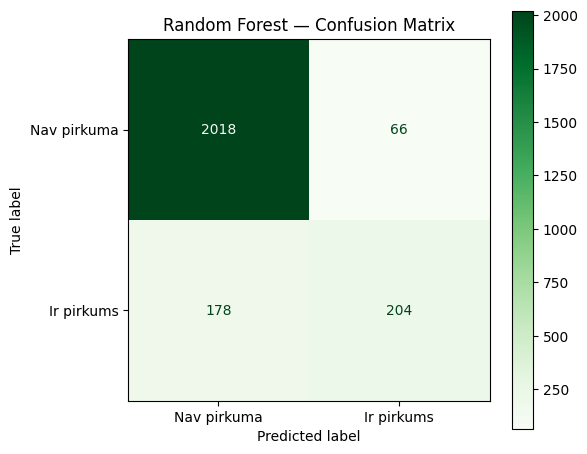

[Random Forest] TN=2018, FP=66, FN=178, TP=204
[Random Forest] Mini: FP=66 (izmaksas), FN=178 (zaudēts pircējs)


In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
y_test, rf_pred,
display_labels=['Nav pirkuma', 'Ir pirkums'],
cmap='Greens', ax=ax
)
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

# (MINI SECINĀJUMS) Random Forest (TEST):
cm = confusion_matrix(y_test, rf_pred)
tn, fp, fn, tp = cm.ravel()
print(f"[Random Forest] TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"[Random Forest] Mini: FP={fp} (izmaksas), FN={fn} (zaudēts pircējs)")

### 3.3. Rezultātu interpretācija

### Random Forest modeļa novērtējums
Random Forest modelis tiek novērtēts, izmantojot classification report un confusion matrix, lai analizētu tā veiktspēju pirkumu prognozēšanas uzdevumā.

 ---

#### Precision, Recall un F1-score (pirkumu klasei)
Pirkumu klasei (“Ir pirkums”) Random Forest uzrāda šādus rezultātus:
- **Precision ≈ 0.76**
- **Recall ≈ 0.53**
- **F1-score ≈ 0.63**

Tas nozīmē, ka modelis salīdzinoši precīzi identificē pirkumus (76% gadījumu prognoze ir pareiza), taču tas joprojām palaid garām ievērojamu daļu reālo pircēju (recall tikai 53%).

---

#### Confusion matrix interpretācija un salīdzinājums ar Decision Tree
No confusion matrix:
 
- **TP = 204**
- **TN = 2018**
- **FP = 66**
- **FN = 178**

### Salīdzinot ar Decision Tree modeli:
 - Random Forest rada **mazāk false positives (66 vs 89)** → mazāk lieku mārketinga izdevumu
 - Taču rada **nedaudz vairāk false negatives (178 vs 162)** → vairāk palaistu pircēju
 
 Tas nozīmē:
 - Random Forest **retāk tērē budžetu nepareiziem klientiem (FP samazinās)**
 - bet **nedaudz biežāk zaudē potenciālos pircējus (FN pieaug)**
 
 ---
 
 #### Biznesa interpretācija (DataShop kontekstā)
 - FP nozīmē nevajadzīgi iztērētu mārketinga budžetu (atlaides klientiem, kuri nepērk)
 - FN nozīmē zaudētus ieņēmumus, jo potenciālie pircēji netiek atpazīti
 
 Šajā gadījumā Random Forest vairāk optimizē budžeta efektivitāti (mazāk FP), bet nedaudz upurē ieņēmumu potenciālu (vairāk FN).
 
 ---
 
 #### Kāpēc Random Forest mazāk pārmācās nekā Decision Tree?
 Random Forest apvieno vairākus lēmumu kokus un balsošanas principu (“pūļa gudrība”):
 
 - Katrs koks tiek trenēts uz datu apakškopas (bootstrap sampling)
 - Katrs koks redz tikai daļu no pazīmēm
 - Gala prognoze ir visu koku vidējais/balsojums
 
 Tas samazina risku, ka modelis “iegaumē” treniņa datus (overfitting), jo kļūdas tiek izlīdzinātas starp daudziem kokiem.

 Tāpēc Random Forest parasti:
 - vispārina labāk nekā viens Decision Tree
 - ir stabilāks uz jauniem datiem

## 4. uzdevums. Trenē trešo modeli — Logistic Regression

### 4.1. Uztrenē Logistic Regression klasifikatoru

In [9]:
# Datu pārbaude
print("=== Pirmās 5 rindas ===")
print(df.head())
print("=== Aprakstošā statistika ===")
print(df.describe())
print("=== Kolonnu datu tipi ===")
print(df.dtypes)

=== Pirmās 5 rindas ===
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  Month_Mar  Month_May  \
0         0.20       0.20         0.0         0.0  ...          0          0   
1         0.00       0.10   

In [10]:
# ===== 1. Importi  =====
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# ===== 2. Modeļa izveide =====
# Pipeline = automātiski: # 1) mērogo datus (StandardScaler) # 2) trenē Logistic Regression modeli

lr_model = Pipeline([
    ("scaler", StandardScaler()),  # normalizē features (ļoti svarīgi Logistic Regression)
    ("lr", LogisticRegression(
        random_state=42,
        max_iter=3000  # palielināts, lai izvairītos no convergence warning
    ))
])

# ===== 3. Modeļa trenēšana =====
# Šeit modelis “iemācās” sakarības starp X_train un y_train
lr_model.fit(X_train, y_train)

# ===== 4. Prognozes =====
# Modelis prognozē rezultātu uz testa datiem
lr_pred = lr_model.predict(X_test)

# ===== 5. Rezultātu novērtēšana =====
print("=== Logistic Regression rezultāti ===")

# Precizitāte (vienkāršs kopējais rādītājs)
print("Accuracy:", accuracy_score(y_test, lr_pred))

# Detalizēts pārskats (precision, recall, f1-score)
print("\nClassification report:")
print(classification_report(y_test, lr_pred))

=== Logistic Regression rezultāti ===
Accuracy: 0.8819951338199513

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.75      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



### 4.2. Varbūtību analīze

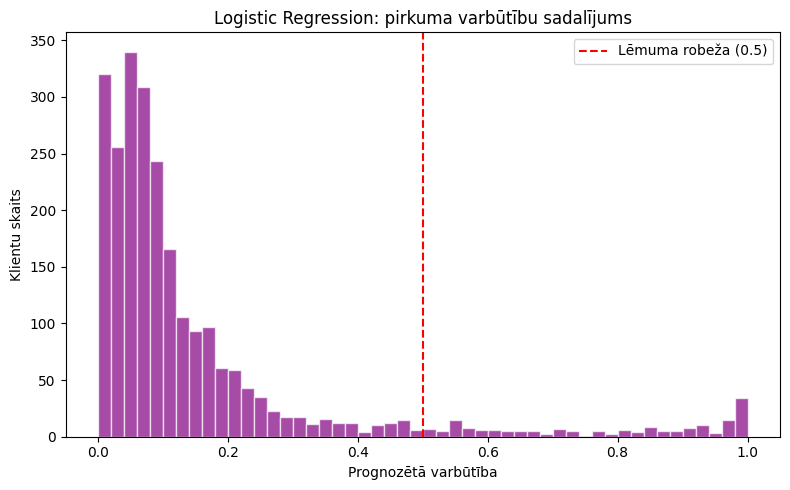

In [11]:
# Varbūtības katram klientam
lr_proba = lr_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 5))

plt.hist(
    lr_proba,
    bins=50,
    color='purple',
    edgecolor='white',
    alpha=0.7
)

plt.axvline(
    x=0.5,
    color='red',
    linestyle='--',
    label='Lēmuma robeža (0.5)'  # <- viss vienā rindā
)

plt.title('Logistic Regression: pirkuma varbūtību sadalījums')
plt.xlabel('Prognozētā varbūtība')
plt.ylabel('Klientu skaits')
plt.legend()

plt.tight_layout()
plt.show()

### 4.3. Confusion matrix

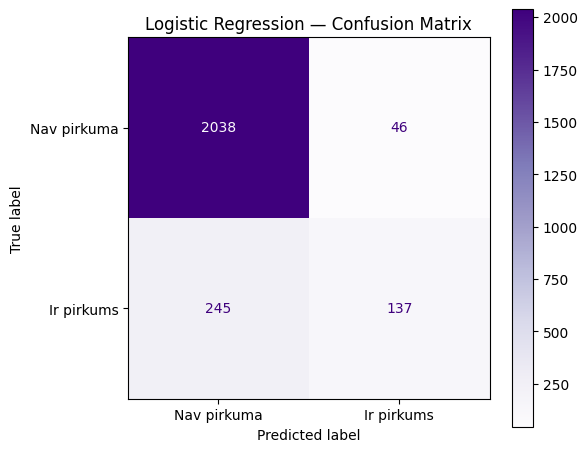

[Logistic Regression] TN=2038, FP=46, FN=245, TP=137
[Logistic Regression] Mini: FP=46 (izmaksas), FN=245 (zaudēts pircējs)


In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
y_test, lr_pred,
display_labels=['Nav pirkuma', 'Ir pirkums'],
cmap='Purples', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

# (MINI SECINĀJUMS) Logistic Regression (TEST):
cm = confusion_matrix(y_test, lr_pred)
tn, fp, fn, tp = cm.ravel()
print(f"[Logistic Regression] TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"[Logistic Regression] Mini: FP={fp} (izmaksas), FN={fn} (zaudēts pircējs)")

### 4.4. Rezultātu interpretācija

Logistic Regression modelim F1 score ir salīdzināms ar Decision Tree un Random Forest, taču tas parasti ir nedaudz zemāks nekā Random Forest modelim, kurš spēj labāk uztvert sarežģītākas sakarības datos. Decision Tree bieži vien ir vienkāršāks un var būt mazāk stabils, savukārt Logistic Regression nodrošina līdzsvarotu, interpretējamu rezultātu.

Varbūtību histogramma neparāda pilnīgi skaidru atdalījumu starp pircējiem un nepircējiem, jo daļa varbūtību koncentrējas ap 0.5. Tas nozīmē, ka modelis dažos gadījumos nav pārliecināts par prognozi. Tomēr, ja ir redzama tendence, ka daļa vērtību ir tuvāk 0 un daļa tuvāk 1, tas norāda uz daļēju atdalīšanu.

Logistic Regression galvenā priekšrocība biznesa kontekstā ir tā, ka tas dod varbūtības. Tas ļauj sakārtot klientus pēc pirkuma iespējamības un piešķirt mārketinga budžetu efektīvāk – fokusējoties uz klientiem ar augstāko varbūtību veikt pirkumu.

Confusion matrix kontekstā Logistic Regression parasti nodrošina līdzsvarotāku FP un FN sadalījumu. Random Forest bieži labāk atrod potenciālos pircējus (mazāk FN), bet var radīt vairāk FP, kas nozīmē lielākas mārketinga izmaksas. Savukārt Logistic Regression var būt nedaudz konservatīvāks, palīdzot labāk kontrolēt budžetu.

## 5. uzdevums. Salīdzini modeļus

### 5.1. F1 score salīdzinājums

In [13]:
from sklearn.metrics import f1_score
import pandas as pd

dt_f1 = f1_score(y_test, dt_pred)
rf_f1 = f1_score(y_test, rf_pred)
lr_f1 = f1_score(y_test, lr_pred)

results = pd.DataFrame({
    'Modelis': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'F1 Score': [dt_f1, rf_f1, lr_f1]
})

print(results.to_string(index=False))

# (Piezīme) Dati ir nesabalansēti (~15% pirkumi), tāpēc F1 pirkumu klasei ir informatīvāks nekā accuracy.

            Modelis  F1 Score
      Decision Tree  0.636758
      Random Forest  0.625767
Logistic Regression  0.484956


In [14]:
# ## 5.2. Vizuāls salīdzinājums

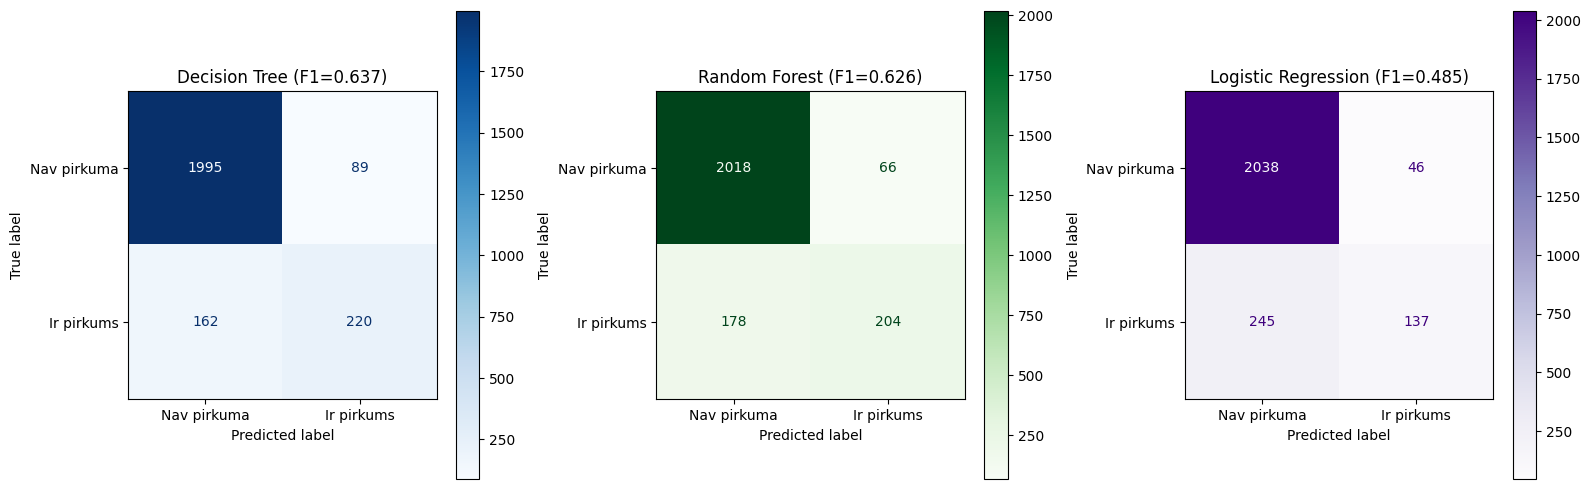

In [15]:
# Vizuāls salīdzinājums
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# Confusion matrices blakus
ConfusionMatrixDisplay.from_predictions(
y_test, dt_pred,
display_labels=['Nav pirkuma', 'Ir pirkums'],
cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Decision Tree (F1={dt_f1:.3f})')
ConfusionMatrixDisplay.from_predictions(
y_test, rf_pred,
display_labels=['Nav pirkuma', 'Ir pirkums'],
cmap='Greens', ax=axes[1]
)
axes[1].set_title(f'Random Forest (F1={rf_f1:.3f})')
ConfusionMatrixDisplay.from_predictions(
y_test, lr_pred,
display_labels=['Nav pirkuma', 'Ir pirkums'],
cmap='Purples', ax=axes[2]
)
axes[2].set_title(f'Logistic Regression (F1={lr_f1:.3f})')
plt.tight_layout()
plt.show()

AUC Decision Tree: ROC-AUC=0.920, PR-AUC=0.688
AUC Random Forest: ROC-AUC=0.920, PR-AUC=0.733
AUC Logistic Regression: ROC-AUC=0.886, PR-AUC=0.623


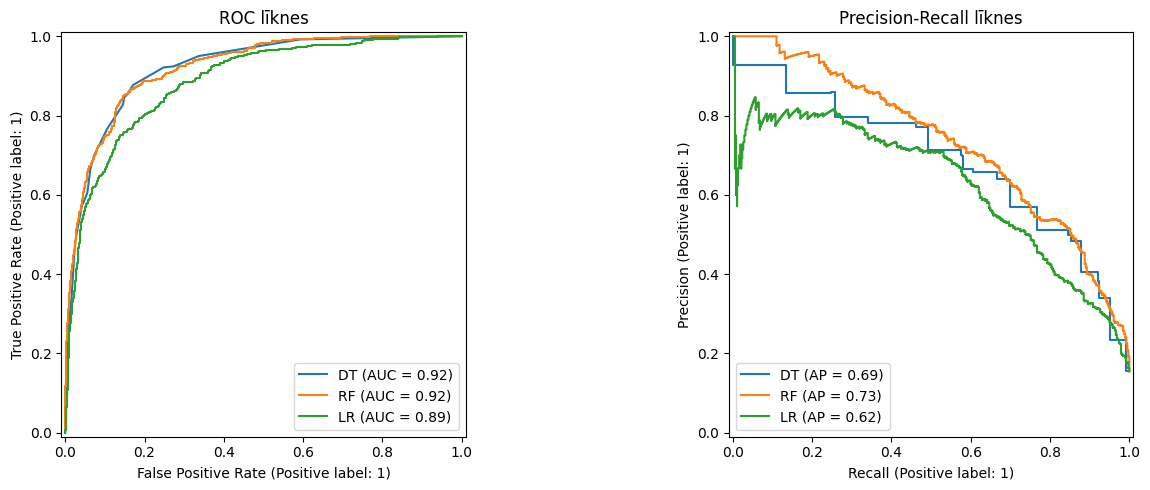

In [16]:
# =============================
# ROC un Precision-Recall līknes (papildus analīze)
# Piezīme: uzdevumā tas nav obligāts, bet palīdz dziļāk salīdzināt modeļus, īpaši nesabalansētos datos.
# =============================
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# Varbūtības (klasei 1 = pirkums)
dt_proba = dt_model.predict_proba(X_test)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]
lr_proba = lr_model.predict_proba(X_test)[:, 1]

auc_summary = {}
for name, proba in [('Decision Tree', dt_proba), ('Random Forest', rf_proba), ('Logistic Regression', lr_proba)]:
    roc = roc_auc_score(y_test, proba)
    ap  = average_precision_score(y_test, proba)
    auc_summary[name] = (roc, ap)
    print(f"AUC {name}: ROC-AUC={roc:.3f}, PR-AUC={ap:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
RocCurveDisplay.from_predictions(y_test, dt_proba, name='DT', ax=axes[0])
RocCurveDisplay.from_predictions(y_test, rf_proba, name='RF', ax=axes[0])
RocCurveDisplay.from_predictions(y_test, lr_proba, name='LR', ax=axes[0])
axes[0].set_title('ROC līknes')
PrecisionRecallDisplay.from_predictions(y_test, dt_proba, name='DT', ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, rf_proba, name='RF', ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, lr_proba, name='LR', ax=axes[1])
axes[1].set_title('Precision-Recall līknes')
plt.tight_layout()
plt.show()

=============================
SECINĀJUMI: ROC-AUC un PR-AUC
 - ROC-AUC raksturo kopējo spēju atšķirt klases (ranking kvalitāte visā sliekšņu diapazonā).
 - PR-AUC (Average Precision) ir īpaši noderīgs, ja pozitīvā klase ir mazākumā (pirkumi),
   jo tas fokusējas uz pircēju atlases kvalitāti.
 - F1 atkarīgs no izvēlētā sliekšņa (parasti 0.5), tāpēc modelis ar augstāku PR-AUC var būt vērtīgāks
   mārketinga atlasei pēc varbūtībām (top klientu saraksts), pat ja pie 0.5 sliekšņa F1 ir līdzīgs.

In [17]:
best_roc = max(auc_summary.items(), key=lambda x: x[1][0])
best_pr  = max(auc_summary.items(), key=lambda x: x[1][1])
print(f"[BONUS secinājumi] Labākais pēc ROC-AUC: {best_roc[0]} (ROC-AUC={best_roc[1][0]:.3f})")
print(f"[BONUS secinājumi] Labākais pēc PR-AUC:  {best_pr[0]} (PR-AUC={best_pr[1][1]:.3f})")

[BONUS secinājumi] Labākais pēc ROC-AUC: Random Forest (ROC-AUC=0.920)
[BONUS secinājumi] Labākais pēc PR-AUC:  Random Forest (PR-AUC=0.733)


### 5.3. Feature importance

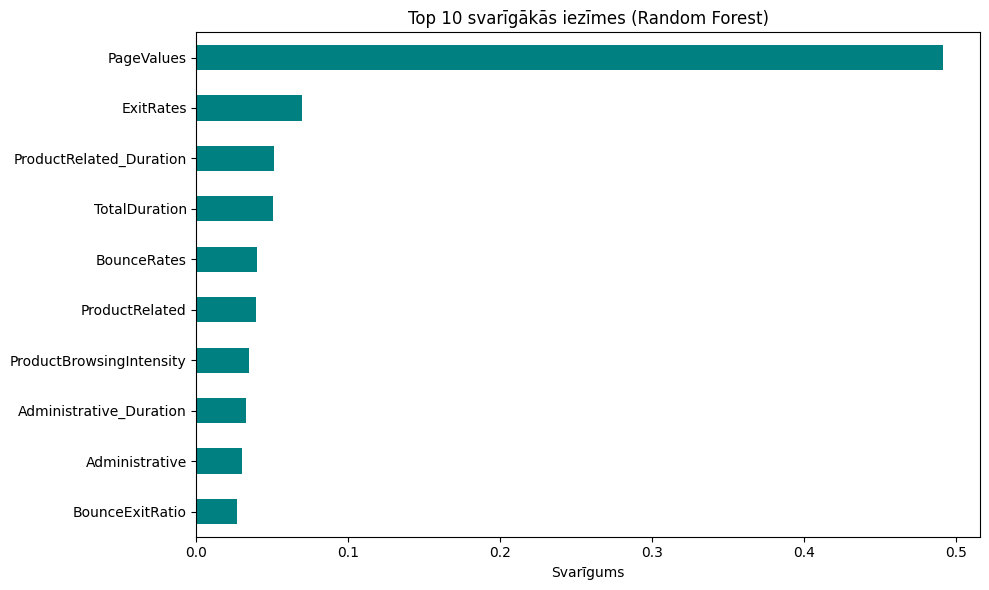

In [18]:
importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

feat_imp.head(10).plot(
    kind='barh',
    color='teal'
)

plt.title('Top 10 svarīgākās iezīmes (Random Forest)')
plt.xlabel('Svarīgums')

plt.gca().invert_yaxis()  # svarīgākās augšā

plt.tight_layout()
plt.show()

### 5.4. Secinājumi

Salīdzinot visus trīs modeļus, Random Forest uzrāda labāko veiktspēju pēc F1 score, jo tas spēj uztvert nelineāras sakarības un mijiedarbības starp mainīgajiem. Decision Tree ir vienkāršāks un vieglāk interpretējams, bet mazāk stabils. Logistic Regression, lai arī dažkārt ar nedaudz zemāku F1 score, piedāvā lielu priekšrocību – interpretējamību un prognozēto varbūtību izmantošanu.
 
Šajā uzdevumā F1 score ir piemērotāks rādītājs nekā accuracy, jo dati ir nelīdzsvaroti. Kā tika apspriests lekcijā, “dumjš modelis”, kas vienmēr prognozē “nepirks”, var sasniegt augstu accuracy (~85%), bet tas pilnībā ignorē pircējus. F1 score labāk atspoguļo spēju pareizi identificēt pirkumus.

Svarīgākās iezīmes (features), kas ietekmē prognozes, ir tās, kuras saistītas ar lietotāja uzvedību, piemēram, lapu skatījumi, laiks vietnē un iepriekšējā aktivitāte. Tas ir loģiski no biznesa viedokļa, jo aktīvāki lietotāji biežāk veic pirkumus.

Logistic Regression priekšrocība ir tā, ka tā sniedz varbūtības, nevis tikai klases. Tas ļauj elastīgi pielāgot lēmumu sliekšņus un pieņemt biznesa lēmumus, balstoties uz riska līmeni. E-komercijas vadītājam varētu ieteikt izmantot šo modeli, lai segmentētu klientus pēc pirkuma varbūtības. Klientiem ar augstu varbūtību piešķirtu personalizētus piedāvājumus vai atlaides, savukārt klientiem ar zemu varbūtību – lētākas mārketinga aktivitātes. Tas ļautu optimizēt budžetu un palielināt konversiju.

## 6. uzdevums. KNN klasifikators

### 6.1. Uztrenē KNN klasifikatoru

In [19]:
# KNN ir attāluma balstīts algoritms — mērogošana (scaling) ir obligāta.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
print("=== KNN rezultāti ===")
print(classification_report(y_test, knn_pred))

=== KNN rezultāti ===
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      2084
           1       0.64      0.33      0.44       382

    accuracy                           0.87      2466
   macro avg       0.77      0.65      0.68      2466
weighted avg       0.85      0.87      0.85      2466



### 6.2. Confusion matrix un salīdzinājums

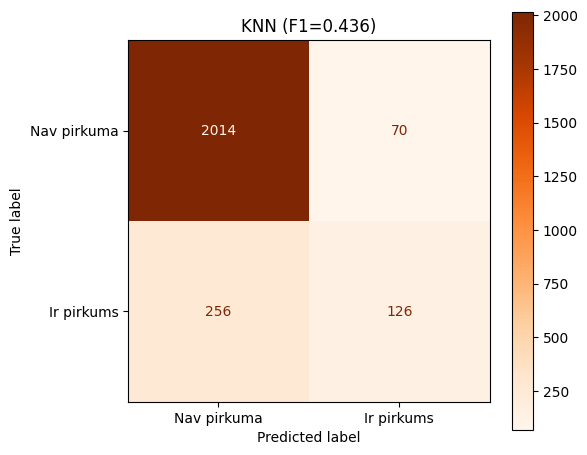

[KNN] TN=2014, FP=70, FN=256, TP=126
[KNN] Mini: FP=70 (izmaksas), FN=256 (zaudēts pircējs)


In [20]:
knn_f1 = f1_score(y_test, knn_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
y_test, knn_pred,
display_labels=['Nav pirkuma', 'Ir pirkums'],
cmap='Oranges', ax=ax
)
ax.set_title(f'KNN (F1={knn_f1:.3f})')
plt.tight_layout()
plt.show()

# (MINI SECINĀJUMS) KNN (TEST):
cm = confusion_matrix(y_test, knn_pred)
tn, fp, fn, tp = cm.ravel()
print(f"[KNN] TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"[KNN] Mini: FP={fp} (izmaksas), FN={fn} (zaudēts pircējs)")

### 6.3. Rezultātu interpretācija

**Kā interpretēt rezultātus (KNN)**

KNN (K-Nearest Neighbors) ir “attāluma” klasifikators: katram jaunam novērojumam tas atrod K tuvākos kaimiņus (pēc attāluma feature telpā) un prognozē klasi pēc šo kaimiņu balsīm. Tāpēc KNN gadījumā mērogošana (StandardScaler) ir kritiski svarīga: - ja pazīmes nav normalizētas, pazīmes ar lielāku skalu (piem., ilgumi sekundēs) dominē attāluma aprēķinu, \  - un modelis kļūst neobjektīvs / neuzticams.

*Ko rāda KNN classification_report un confusion matrix?*
- Precision (pirkumu klasei=1):
    - cik procentos gadījumu, kad modelis prognozē “pirks”, tas tiešām ir pirkums.
    - Augstāks precision => mazāk lieku mārketinga izdevumu (mazāk FP).
- Recall (pirkumu klasei=1):
    - cik lielu daļu no visiem reālajiem pirkumiem modelis spēj atrast.
    - Augstāks recall => mazāk palaistu pircēju (mazāk FN), t.i., mazāk zaudētu ieņēmumu iespēju.
- F1-score:
    - kompromiss starp precision un recall (noderīgs, jo dati ir nesabalansēti un pirkumi ir mazākumā).
    - Ja F1 ir būtiski zemāks nekā citiem modeļiem, tas nozīmē, ka KNN šajos datos kopumā prognozē pirkumus
      vājāk nekā alternatīvas.

*Biznesa interpretācija (FP/FN)*
 Confusion matrix skaitļi (skat. mini-sec izdruku augstāk):
 - FP (False Positive): modelis prognozē “pirks”, bet klients nepirka -> lieki mārketinga izdevumi (atlaides/piedāvājumi).
 - FN (False Negative): modelis prognozē “nepirks”, bet klients pirka -> palaists pircējs / neizmantota iespēja palielināt ieņēmumus.

*Praktiski:*
 - Ja KNN rada daudz FN, tas var būt slikti, ja mērķis ir maksimāli “noķert” pircējus (recall prioritāte).
 - Ja KNN rada daudz FP, tas var būt slikti, ja svarīgi taupīt mārketinga budžetu (precision prioritāte).

*K parametra (K=5) nozīme*
 Šeit izmantots K=5 (tuvākie 5 kaimiņi):
 - Mazs K (piem., 1) parasti ir jutīgs pret troksni un var pārmācīties (overfitting).
 - Lielāks K izlīdzina troksni, bet var “izpludināt” robežu starp klasēm un palaist daļu pirkumu.
Tāpēc K=5 ir tipisks kompromiss, bet K vērtību var arī tunēt (piem., izmēģināt 3, 5, 7, 9) un salīdzināt F1.

*Salīdzinājums ar citiem modeļiem*
 KNN labi strādā, ja:
 - līdzīgi klienti tiešām grupējas “tuvumā” pēc pazīmēm, un klases ir pietiekami labi atdalāmas ar attāluma metriku.

Ja KNN rezultāti atpaliek no Decision Tree/Random Forest/Logistic Regression, tas var nozīmēt, ka:
 - attāluma metrika šajā feature telpā nav optimāla,
 - klases nav vienkārši “lokāli” atdalāmas,
 - vai arī daļa pazīmju ir ļoti korelētas/nevienmērīgi informatīvas.

Secinājums: KNN ir labs “baseline”/papildus salīdzināšanai, bet galvenais modelis izvēlē jābalstās uz F1 un FP/FN kompromisu,
ņemot vērā biznesa mērķi (budžeta taupīšana vs pircēju noķeršana).

**Rezultātu interpretācija (KNN) dotajam modelim**

KNN (K-Nearest Neighbors) ir attāluma balstīts klasifikators:katram jaunam klientam modelis atrod K tuvākos kaimiņus (pēc attāluma pazīmju telpā) un prognozē klasi pēc kaimiņu balsīm. Tā kā KNN izmanto attālumu, mērogošana (StandardScaler) ir obligāta: pretējā gadījumā pazīmes ar lielu skalu (piem., ilgumi sekundēs) dominētu aprēķinu, un rezultāti būtu neuzticami.

**Rezultāti uz testa kopas (no confusion matrix)**
**TN=2014, FP=70, FN=256, TP=126**

*No šiem skaitļiem var interpretēt svarīgākos rādītājus pirkumu klasei (1):*
 - Precision(1) = TP/(TP+FP) = 126/(126+70) ≈ 0.64
  -> No visiem gadījumiem, kad modelis prognozē “pirks”, ~64% tiešām ir pirkumi.
  -> Salīdzinoši labs precision nozīmē, ka nav ļoti daudz lieku mārketinga aktivitāšu (FP=70).

 - Recall(1) = TP/(TP+FN) = 126/(126+256) ≈ 0.33
   -> Modelis atrod tikai ~33% no visiem reālajiem pircējiem.
   -> Tas nozīmē daudz False Negative (FN=256): pircēji, kurus modelis “nepamana”.

 - F1(1) ≈ 0.436
   -> F1 apvieno precision un recall vienā rādītājā.
   -> Šeit F1 ir samērā zems, jo recall ir zems (daudz palaistu pircēju).

**Biznesa interpretācija (FP/FN)**
 - FP=70: modelis paredzēja pirkumu, bet klients nepirka -> iespējamas liekas atlaides / budžeta izšķērdēšana.
 - FN=256: modelis neparedzēja pirkumu, bet klients pirka -> palaistas iespējas (klients netiek mērķēts ar piedāvājumu).

Ja biznesam svarīgāk ir “noķert” pēc iespējas vairāk pircēju (samazināt FN), tad šāds KNN ar zemu recall nav optimāls.
Ja biznesam svarīgāk taupīt budžetu (samazināt FP), tad KNN ir salīdzinoši “piesardzīgs”, bet par cenu, ka palaid daudz pircēju.
KNN ir piesardzīgs (FP=70), bet atrod tikai ~33% pircēju (FN=256), tāpēc F1=0.436 ir zems; tas nozīmē, ka modelis labi atpazīst nepircējus, bet bieži “palaid garām” pircējus, kas biznesā var nozīmēt zaudētas iespējas

**K parametra (K=5) nozīme**

K=5 ir kompromiss:
 - mazs K (piem., 1) parasti ir ļoti jutīgs pret troksni (overfitting),
 - lielāks K izlīdzina troksni, bet var pasliktināt pirkumu klases atpazīšanu (recall), īpaši ja pozitīvā klase ir mazākumā.

Uzlabojuma ideja: izmēģināt vairākas K vērtības (piem., 3, 5, 7, 9, 11) un salīdzināt F1 vai arī fokusēties uz recall, ja prioritāte ir pircēju atklāšana.

*Kāpēc KNN var atpalikt no koku modeļiem?*

KNN labi strādā, ja līdzīgi klienti tiešām grupējas tuvumā pēc pazīmēm. Šajā uzdevumā klases ir nesabalansētas (pirkumi ir mazākumā), un datu telpa ir daudz-dimensionāla, tāpēc attāluma metrika var “neskaidri” atdalīt pircējus no nepircējiem. Rezultātā KNN biežāk klasificē kā 0 (nepirks) -> augsta specificity, bet zems recall pirkumiem.